In [1]:
import uproot ## means uproot4
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
import numpy as np
import awkward as ak
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

filedict={ 
     'ttH': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWminus':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_Ntuple/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
     'ggF': '/home/pku/zhaoyz/Higgs/MCvsDATA/MiniIso/2017/Signal_MERGED/HWW_Ntuple.root',
    
     'ttH_any': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWminus_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ_any':'/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF_any': '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
     'ggF_any' :  '/home/pku/zhaoyz/Ntuple/OtherChannels/MERGED_NtupleAnyNj8/2017/GluGluHToWW_Pt-200ToInf_M-125_TuneCP5_MINLO_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
    
     'HWminus_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HWminusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HWplus_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HWplusJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'HZ_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/HZJ_HToWW_M-125_TuneCP5_13TeV-powheg-jhugen727-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'VBF_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/VBFHToWWToLNuQQ_M-125_TuneCP5_withDipoleRecoil_13TeV_powheg_jhugen751_pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v3/MERGED.root',
     'ttH_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root',
     'ggF_wo':'/home/pku/zhaoyz/CustNano/OtherChannels/MERGED_2017/2017/GluGluHToWW_Pt-200ToInf_M-125_TuneCP5_MINLO_13TeV-powheg-pythia8_RunIISummer20UL17MiniAODv2-106X_mc2017_realistic_v9-v2/MERGED.root'
}


events = {key: {} for key in filedict}

for key in filedict:
    events[key] = uproot.lazy({filedict[key]: "Events"}) ## lazy means lazy computation style
    ## optional: uproot.lazy({ "$FILEPATH": "TTree", ...}) or uproot.lazy(["$FILEPATH:TTree", ...])
        

In [2]:
events['VBF_wo']

<Array [{run: 1, ... L1simulation_step: True}] type='280000 * {"run": uint32, "l...'>

In [3]:
FileWO = ['HWminus_wo','HWplus_wo','HZ_wo','VBF_wo','ttH_wo','ggF_wo']
events_cut1 = {key: {} for key in FileWO}

In [4]:
# events_cut1['ttH_wo'] = events[key]['FatJet_pt'][events[key]['nFatJet'] > 0]
# events_cut1['ttH_wo']

In [5]:
# events_cut1['ttH_wo'] = events[key]['FatJet_pt']
# events_cut1['ttH_wo']

In [6]:
for key in FileWO:
#     events_cut1[key] = events[key]['FatJet_pt'][events[key]['nFatJet'] > 0] 
    events_cut1[key] = events[key]['FatJet_pt']
events_cut1['VBF_wo']

<Array [[], [192], [], [], ... [], [], [], []] type='280000 * var * float32'>

In [7]:
events_cut1['ggF_wo']

<Array [[221], [333, 318, ... 311], [229, 201]] type='496999 * var * float32'>

In [22]:
0.101*41.5*1000/496999

0.008433618578709414

In [8]:
# for key in FileWO:
#     events_cut1[key] = events[key]['FatJet_pt']
# events_cut1['VBF_wo']

In [9]:
# np.sum(events_cut1['VBF_wo']>0,axis = 1)

In [10]:
Nj8_cut1 = {key: {} for key in FileWO}
for key in FileWO :
    Nj8_cut1[key] = np.sum(events_cut1[key]>200,axis=1)
Nj8_cut1['VBF_wo']

<Array [0, 0, 0, 0, 0, 1, ... 0, 0, 0, 0, 0, 0] type='280000 * int64'>

In [11]:
events_cut2 = {key: {} for key in FileWO}
for key in FileWO:
    events_cut2[key] = events[key]['FatJet_pt'][events[key]['nFatJet'] > 0] 
    events_cut2[key] = events_cut2[key][np.max(events_cut2[key],axis=1) > 400 ] 
#     events_cut2[key] = events_cut2[key] != None
events_cut2['VBF_wo']

<Array [[406, 249], [539, ... [462, 348, 318]] type='1209 * option[var * float32]'>

In [12]:
Nj8_cut2 = {key: {} for key in FileWO}
for key in FileWO :
    Nj8_cut2[key] = np.sum(events_cut2[key]>200,axis=1)
Nj8_cut2['VBF_wo']

<Array [2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 3] type='1209 * ?int64'>

In [13]:
FileAny = ['HWminus_any','HWplus_any','HZ_any','VBF_any','ttH_any', 'ggF_any']
Nj8_Any = {key: {} for key in FileAny}
for key in  FileAny:
    Nj8_Any[key] = np.sum(events[key]['FatJet_pt']>200,axis=1)
Nj8_Any['VBF_any']

<Array [2, 2, 1, 2, 2, 2, ... 2, 2, 2, 2, 2, 2] type='498 * int64'>

In [41]:
Nj8_Any['ggF_any']

<Array [2, 2, 1, 2, 2, 3, ... 3, 3, 2, 3, 2, 3] type='30945 * int64'>

In [49]:
# FileFinal = ['HWminus','HWplus','HZ','VBF','ttH', 'ggF']
# Nj8_Final = {key: {} for key in FileFinal}
FileAny = ['HWminus_any','HWplus_any','HZ_any','VBF_any','ttH_any', 'ggF_any']
Nj8_Final = {key: {} for key in FileAny}
for key in FileAny :
#     Nj8_Final[key] = np.sum(events[key]['FatJet_pt']>200,axis=1)

    Nj8_Final[key] =  Nj8_Any[key][ Nj8_Any[key] > 1]
Nj8_Final['VBF_any']

<Array [2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2] type='471 * int64'>

In [51]:
Nj8_Final['ggF_any']

<Array [2, 2, 2, 2, 3, 3, ... 3, 3, 2, 3, 2, 3] type='29850 * int64'>

In [52]:
29241*0.008

233.928

In [117]:
def plot(sample, variable, weight,x ,y, name, bins=5, x_min=0, x_max=5, density=False, stack=False):
    ## canvas initializing
    colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    fig = plt.figure(figsize=(9,9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year="2017", ax=ax)
    
#     for Samples in sample.keys():
#         print(Samples)
        
    
#     ## plot
#     hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
    labelDict = {
        'ttH':'ttH(nonbb)',
        'VBF':'VBFH(WW)(qqlnu)' ,
        'ggF':'ggH(WW)-Pt200',
        'HWminus'   :'WminusH(WW)',
        'HWplus'   :'WplusH(WW)',
        'HZ'   :'ZH(WW)',
    
    }
    i = 0
    for Samples in sample.keys():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
#         hist.scale(weight.get(Samples))
#         values = sample.get(Samples)[variable]
        values = sample.get(Samples)
        hist.fill(values, weight=weight[Samples])
        h, err = hist.view().value, np.sqrt(hist.view().variance)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=labelDict[Samples], histtype='step', stack=stack)
        
#     values = sample.get("VBF")[variable]
# #     print(values)
#     hist.fill(values)
#     h, err = hist.view().value, np.sqrt(hist.view().variance)
#     hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label='VBFHToWWToLNuQQ', histtype='step', density=density, stack=stack)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
        plt.xlim(x_min, x_max)
        plt.ylim(0, ax.get_ylim()[1]*1.1)
        ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
        if density==False:
            plt.ylabel('Events', fontsize=20, ha='right', y=1)
        elif density==True:    
            plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
        plt.xlabel('Number of AK8 jets(pT > 200GeV)', fontsize=20, ha='right', x=1)

        plt.xticks(size=16)
        plt.yticks(size=16)


    ## title, text and legend
#         plt.title(name, fontsize=24,color="black")
        plt.legend(loc="best", ncol=1, frameon=False, fontsize=20)
        if i == 0:
            plt.text(x*ax.get_xlim()[1], ax.get_ylim()[1]*y,name, fontsize=18, color="black", ha='right')
            i += 1
#         plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')
        

    ## finalizing
        if density==True:   suffix='_AU'
        else : suffix='Events'
        if stack==True:     suffix='_stack'
    plt.savefig('filename'+ name +".pdf", bbox_inches='tight')
#     plt.show()
    return fig

In [118]:


WeightDict = {
    "HWminus": 0.000697,
    "HWplus" : 0.001078,
    "HZ"     : 0.001306,
    "VBF"    : 0.05188,
    "ttH"    : 0.001567,
    "ggF"    : 0.00826,
    
}



EventsList_Nj8_Cut1 = {"HWminus":Nj8_cut1['HWminus_wo'],
              "HWplus":Nj8_cut1['HWplus_wo'],
              "HZ":Nj8_cut1['HZ_wo'],
              "VBF":Nj8_cut1['VBF_wo'],
              "ttH":Nj8_cut1['ttH_wo'],
              "ggF":Nj8_cut1['ggF_wo'],
                      }


EventsList_Nj8_Cut2 = {"HWminus":Nj8_cut2['HWminus_wo'],
              "HWplus":Nj8_cut2['HWplus_wo'],
              "HZ":Nj8_cut2['HZ_wo'],
              "VBF":Nj8_cut2['VBF_wo'],
              "ttH":Nj8_cut2['ttH_wo'],
              "ggF": Nj8_cut2['ggF_wo'],
                      }




EventsList_Nj8_Any = {"HWminus":Nj8_Any['HWminus_any'],
              "HWplus":Nj8_Any['HWplus_any'],
              "HZ":Nj8_Any['HZ_any'],
              "VBF":Nj8_Any['VBF_any'],
              "ttH":Nj8_Any['ttH_any'],
              "ggF":Nj8_Any['ggF_any'],
                     }



EventsList_Nj8_Final = {"HWminus":Nj8_Final['HWminus_any'],
              "HWplus":Nj8_Final['HWplus_any'],
              "HZ":Nj8_Final['HZ_any'],
              "VBF":Nj8_Final['VBF_any'],
              "ttH":Nj8_Final['ttH_any'],
              "ggF":Nj8_Final['ggF_any'],
                       }

ax1 = plot(sample=EventsList_Nj8_Cut1,variable = "FatJet",weight = WeightDict ,name ="Without any selection",x = 0.4 , y = 2.85)
plt.ylim((0,16000))
ax2 = plot(sample=EventsList_Nj8_Cut2,variable = "FatJet",weight = WeightDict, name = "With leading pT > 400GeV",x = 0.5 , y = 12)
plt.ylim((0,500))
ax3 = plot(sample=EventsList_Nj8_Any,variable = "FatJet",weight = WeightDict, name = "With Selection.1",x = 0.3 , y = 11)
plt.ylim((0,300))
ax4 = plot(sample=EventsList_Nj8_Final,variable = "FatJet",weight = WeightDict, name = "With Selection.2",x = 0.3 , y = 11)
plt.ylim((0,300))

(0.0, 300.0)

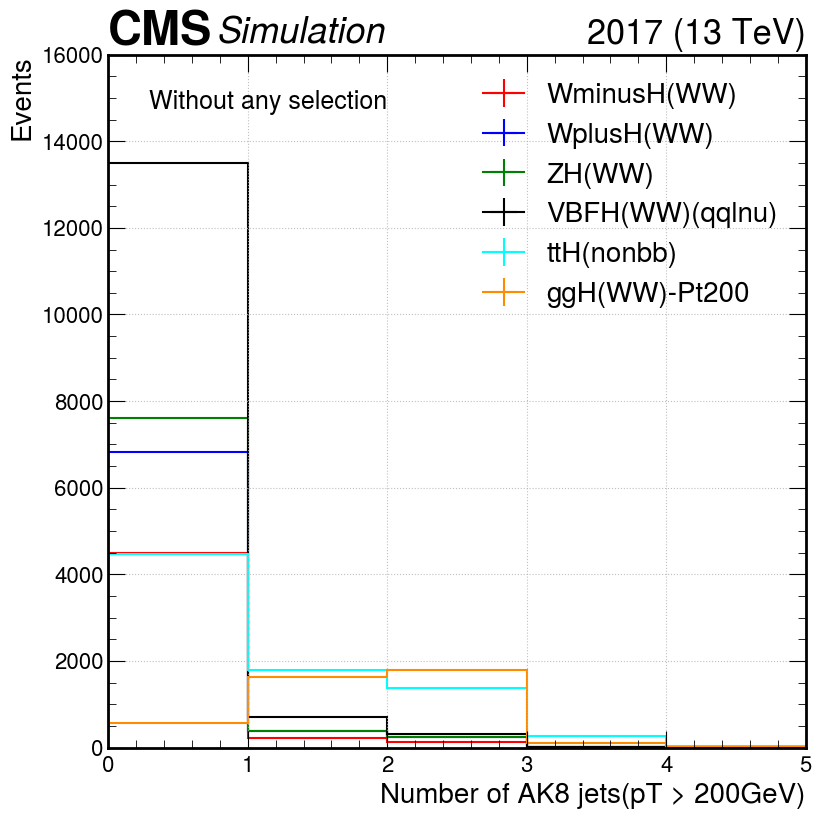

In [119]:
ax1

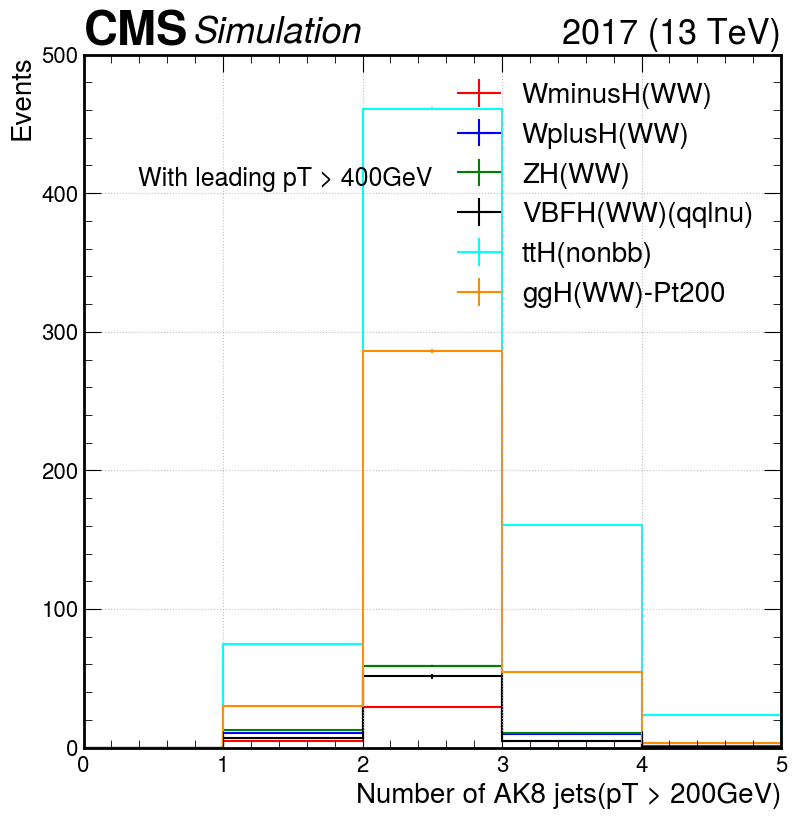

In [120]:
ax2

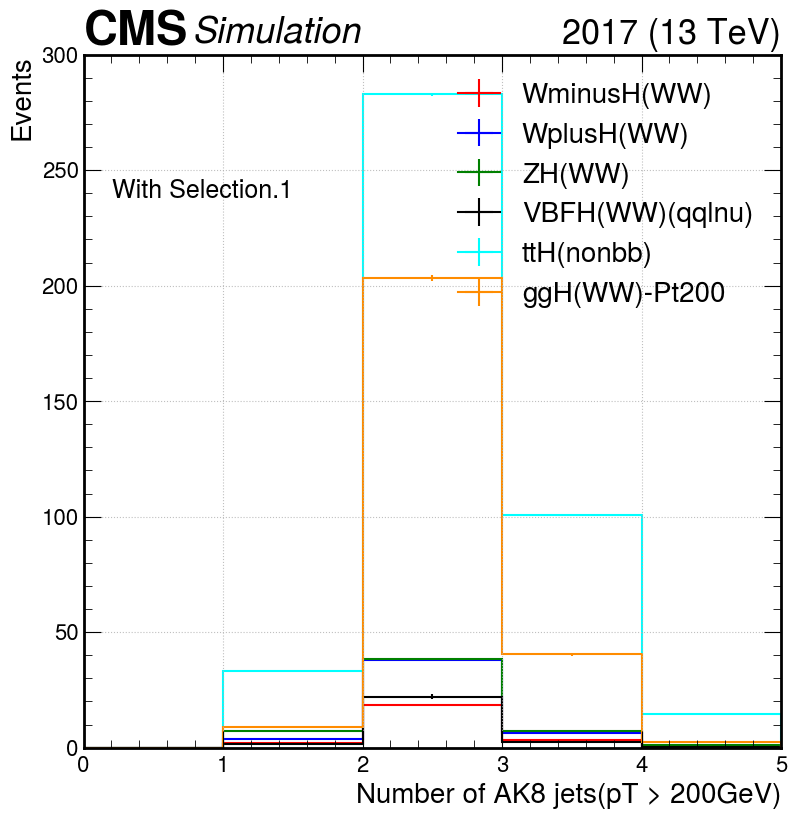

In [121]:
ax3

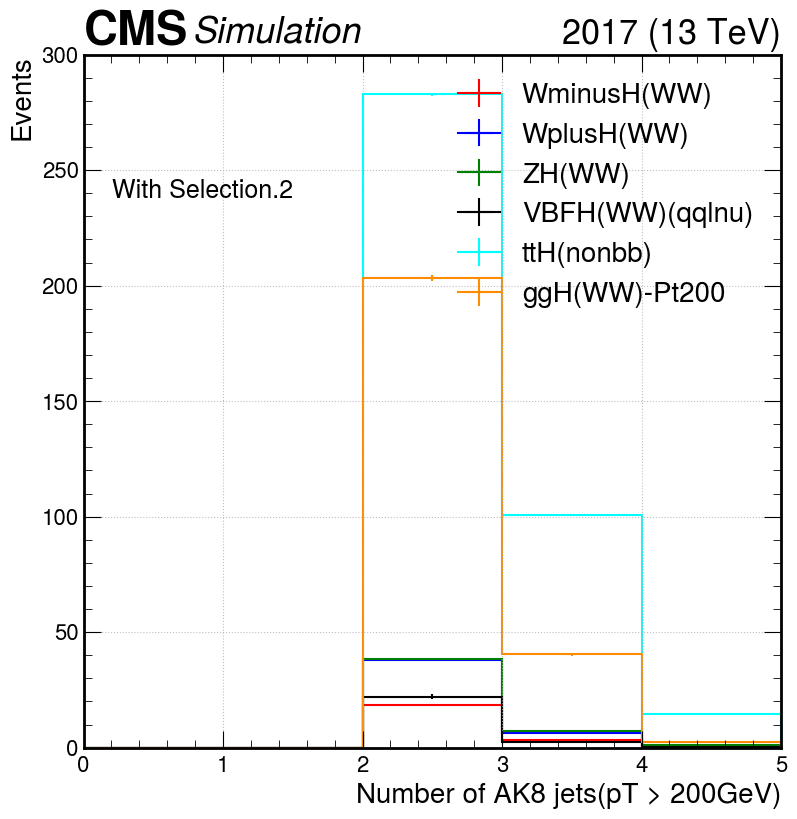

In [122]:
ax4